# 994. Rotting Oranges

Companies
You are given an m x n grid where each cell can have one of three values:

0 representing an empty cell,
1 representing a fresh orange, or
2 representing a rotten orange.
Every minute, any fresh orange that is 4-directionally adjacent to a rotten orange becomes rotten.

Return the minimum number of minutes that must elapse until no cell has a fresh orange. If this is impossible, return -1.

 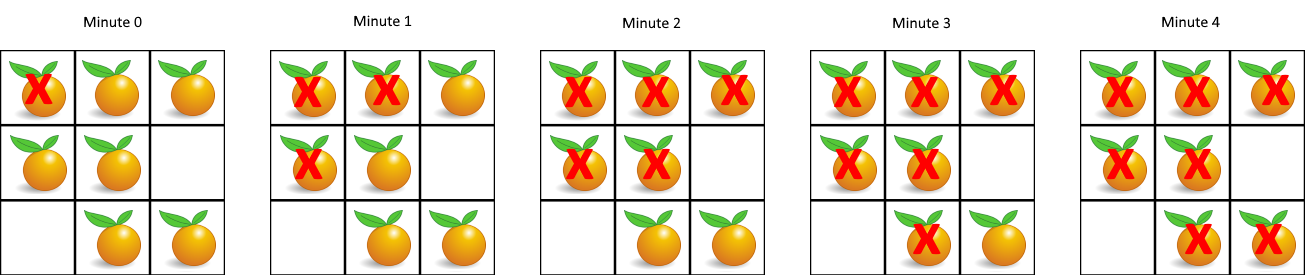

Input: grid = [[2,1,1],[1,1,0],[0,1,1]]
Output: 4

In [ ]:
from typing import List
from collections import deque

NONE = 0
FRESH = 1
ROTTEN = 2

DIRECTIONS = [(0, 1), (1, 0), (-1, 0), (0, -1)]

class Solution:
    def orangesRotting(self, grid: List[List[int]]) -> int:
        ROWS, COLS = len(grid), len(grid[0])
        queue = deque()
        fresh_count = 0

        # Phase 1: seed all rotten oranges into the queue and count fresh ones
        for r in range(ROWS):
            for c in range(COLS):
                if grid[r][c] == ROTTEN:
                    queue.append((r, c))
                elif grid[r][c] == FRESH:
                    fresh_count += 1
        if fresh_count == 0: 
            return 0
        if len(queue) == 0:
            return -1
      
        return self.bfs(grid, queue, ROWS, COLS, fresh_count)

    def bfs(self,grid, queue, rows, cols, fresh_count) -> int:
            minutes = 0
            # Each level of BFS = 1 minute elapsed
            while queue and fresh_count > 0:
                # Spread rot to all neighbours at the current frontier
                for _ in range(len(queue)):
                    r, c = queue.popleft()
                    for dr, dc in DIRECTIONS:
                        nr, nc = r + dr, c + dc
                        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == FRESH:
                            grid[nr][nc] = ROTTEN
                            fresh_count -= 1
                            queue.append((nr, nc))
                minutes += 1

            # If fresh oranges remain they are unreachable
            return minutes if fresh_count == 0 else -1
